In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor 

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error

### Just change this if ever use this in future

In [33]:
# Setting Up A Default Path & Target
CSV_PATH = ("./Housing.csv")
TARGET_COL = "price_log"

In [34]:
df= pd.read_csv(CSV_PATH)

In [35]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


### Fix if needed

In [36]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

### Checking for encoded missing values

In [37]:
for col in df.columns:
    print(df[col].value_counts().head(20), "\n")

price
4200000    17
3500000    17
4900000    12
5250000     9
5600000     9
3150000     9
3640000     9
3290000     8
3360000     8
5950000     8
2940000     8
4550000     7
3010000     7
3920000     7
3850000     7
2660000     7
4270000     6
4690000     6
6650000     6
3430000     6
Name: count, dtype: int64 

area
6000    24
3000    14
4500    13
4000    11
6600     9
5500     9
3600     8
3180     7
4040     7
3640     7
3630     7
6360     7
5400     6
2145     6
3500     6
7000     5
3850     5
3450     5
4600     5
3480     5
Name: count, dtype: int64 

bedrooms
3    300
2    136
4     95
5     10
6      2
1      2
Name: count, dtype: int64 

bathrooms
1    401
2    133
3     10
4      1
Name: count, dtype: int64 

stories
2    238
1    227
4     41
3     39
Name: count, dtype: int64 

mainroad
yes    468
no      77
Name: count, dtype: int64 

guestroom
no     448
yes     97
Name: count, dtype: int64 

basement
no     354
yes    191
Name: count, dtype: int64 

hotwaterheating
no

### Classifying the columns 
#### Numerical / Categorical

In [38]:
# Get numerical columns
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# Get categorical columns (Objects and Categories)
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical: {num_cols}")
print(f"Categorical: {cat_cols}")

Numerical: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


### Data Visualization (Count Plot)

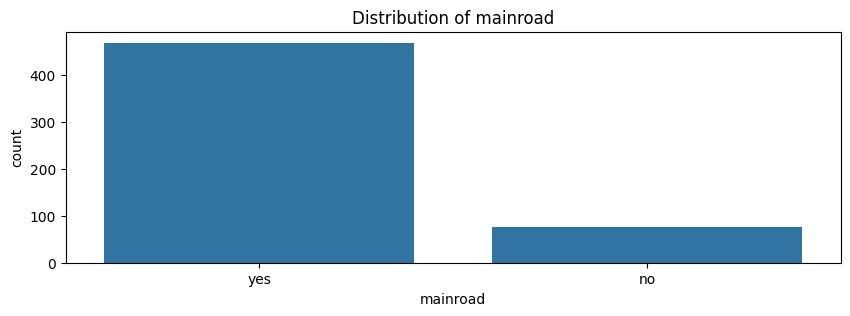

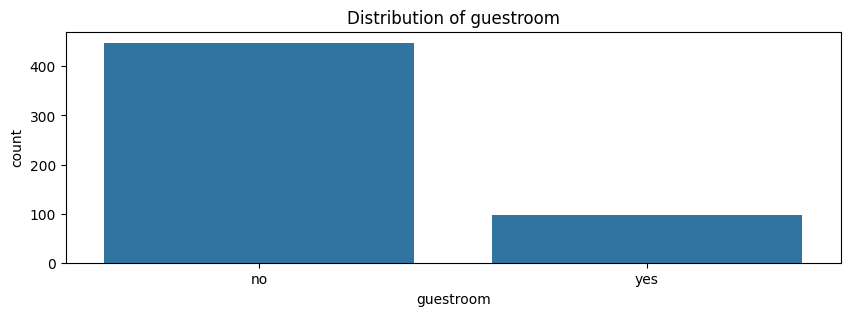

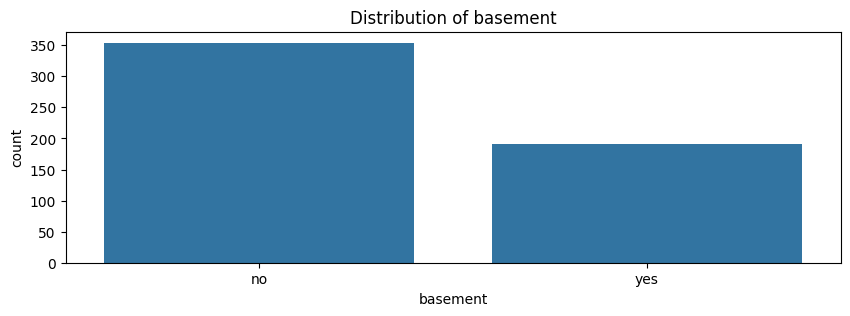

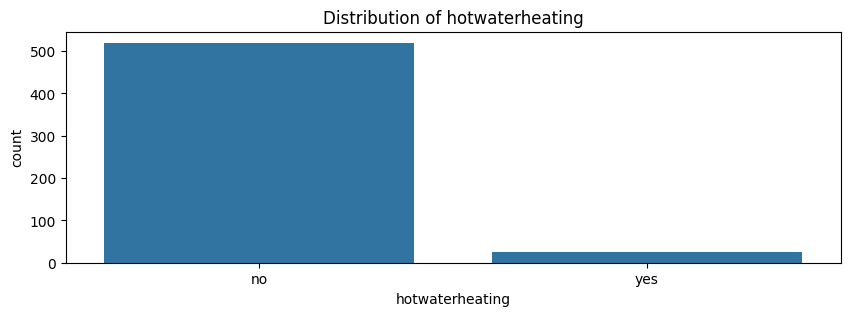

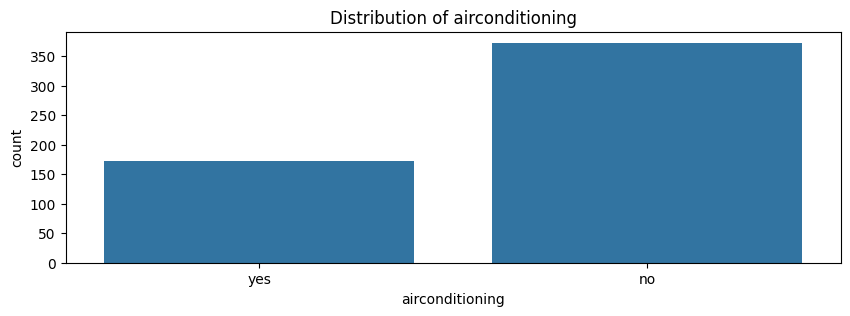

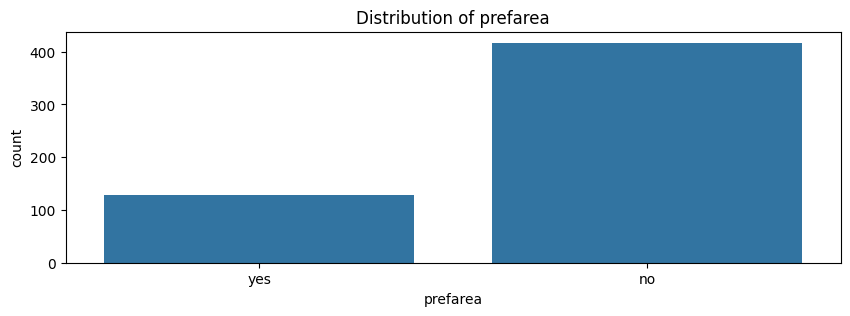

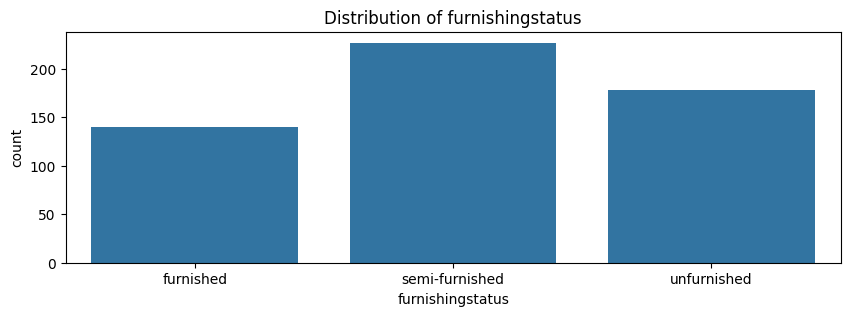

In [39]:
for col in cat_cols:
    plt.figure(figsize=(10,3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

### Analyzing the target Column

In [40]:
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COL], bins=69)
plt.show()

KeyError: 'price_log'

<Figure size 600x400 with 0 Axes>

### So this is Right Skewed will fix later

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=69)
    plt.show()

### Price, Area are Right Skewed

### Insights From The EDA

mainroad	Binary (0/1)
guestroom	Binary (0/1)
basement	Binary (0/1)
hotwaterheating	Binary (0/1)
airconditioning	Binary (0/1)
prefarea	Binary (0/1)
furnishingstatus	Ordinal	Clear hierarchy (None < Some < Full)

TargetColumn PRICE Right Skewed
AREA Right Skewed

# PREPROCESSING START

In [41]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

KeyError: "['price_log'] not found in axis"

In [ ]:
X.head(5)

In [42]:
y.head(5)

0    16.403275
1    16.321037
2    16.321037
3    16.318175
4    16.250001
Name: price_log, dtype: float64

### Creating TTS

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

### Creating ML Pipeline

In [44]:
num_cols

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

In [45]:
cat_cols

['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea',
 'furnishingstatus']

In [46]:
num_transformer = Pipeline(
    steps=[
        ("Imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

cat_transformer = Pipeline(
    steps=[
        ("Imputer", SimpleImputer(strategy="most_frequent")),
        ("OHE", OneHotEncoder(handle_unknown="ignore"))
        ])


In [47]:
df.replace({"yes":1, "no":0}, inplace=True)

C:\Users\anuve\AppData\Local\Temp\ipykernel_15556\993254578.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"yes":1, "no":0}, inplace=True)


In [48]:
status_map = {
    "unfurnished":0,
    "semi-furnished":1,
    "furnished":2
}

df["furnishingstatus"] = df["furnishingstatus"].map(status_map)

In [49]:
df["price_log"] = np.log1p(df["price"])

In [50]:
X = df.drop(columns=["price", "price_log"])
y = df["price_log"]

In [51]:
df["area_log"] = np.log1p(df["area"])

In [52]:
preprocess = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

In [32]:
from sklearn.ensemble import RandomForestRegressor

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=42))
])

pipe.fit(X_train, y_train)

ValueError: A given column is not a column of the dataframe

In [27]:
y = df["price"]

In [53]:
# ================= HARD RESET =================

# reload clean data
df = pd.read_csv("./Housing.csv")

# encoding
df.replace({"yes":1, "no":0}, inplace=True)

status_map = {
    "unfurnished":0,
    "semi-furnished":1,
    "furnished":2
}
df["furnishingstatus"] = df["furnishingstatus"].map(status_map)

# target transform
df["price_log"] = np.log1p(df["price"])

# features & target
X = df.drop(columns=["price", "price_log"])
y = df["price_log"]

# split AGAIN (IMPORTANT)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# column lists FROM X
num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(exclude="number").columns

print("✅ Reset complete")

✅ Reset complete


C:\Users\anuve\AppData\Local\Temp\ipykernel_15556\2414844713.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"yes":1, "no":0}, inplace=True)


In [54]:
pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=42))
])

pipe.fit(X_train, y_train)

ValueError: A given column is not a column of the dataframe

In [55]:
print(X_train.columns)

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [56]:
# ===== DESTROY OLD OBJECTS =====
del preprocess
del pipe

# ===== RECREATE COLUMN LISTS =====
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

# ===== REBUILD PREPROCESSOR =====
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

# ===== NEW PIPELINE =====
pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=42))
])

print("✅ Fresh pipeline created")

✅ Fresh pipeline created


In [57]:
pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [60]:
pred_log = pipe.predict(X_test)

rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))
r2 = r2_score(y_test, pred_log)

pred_price = np.expm1(pred_log)
true_price = np.expm1(y_test)
rmse_price = np.sqrt(mean_squared_error(true_price, pred_price))

print("R2 Score:", r2)
print("RMSE (log):", rmse_log)
print("RMSE (₹):", rmse_price)

R2 Score: 0.6329959860411303
RMSE (log): 0.2662035054393292
RMSE (₹): 1418119.6065544703


In [61]:
from sklearn.ensemble import GradientBoostingRegressor

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(random_state=42))
])

In [62]:
pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
pred_log = pipe.predict(X_test)

rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))
r2 = r2_score(y_test, pred_log)

pred_price = np.expm1(pred_log)
true_price = np.expm1(y_test)
rmse_price = np.sqrt(mean_squared_error(true_price, pred_price))

print("R2 Score:", r2)
print("RMSE (log):", rmse_log)
print("RMSE (₹):", rmse_price)

R2 Score: 0.6652895360875901
RMSE (log): 0.2542219278812396
RMSE (₹): 1346010.3636969335


In [64]:
# ==============================
# TRAIN & RANK MULTIPLE MODELS
# ==============================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# MODELS
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# ------------------------------
# LOAD DATA
# ------------------------------
df = pd.read_csv("Housing.csv")

# target
y = np.log1p(df["price"])   # log transform
X = df.drop(columns=["price"])

# ------------------------------
# COLUMN TYPES
# ------------------------------
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

# ------------------------------
# PREPROCESSOR
# ------------------------------
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# ------------------------------
# TRAIN TEST SPLIT
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------
# MODELS TO TEST
# ------------------------------
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

# ------------------------------
# TRAIN + EVALUATE
# ------------------------------
results = []

for name, model in models.items():

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    preds_log = pipe.predict(X_test)

    # metrics
    r2 = r2_score(y_test, preds_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, preds_log))

    # convert back to rupees
    preds_real = np.expm1(preds_log)
    y_real = np.expm1(y_test)

    rmse_real = np.sqrt(mean_squared_error(y_real, preds_real))

    results.append([name, r2, rmse_log, rmse_real])

# ------------------------------
# RANK RESULTS
# ------------------------------
results_df = pd.DataFrame(
    results,
    columns=["Model", "R2 Score", "RMSE (log)", "RMSE (₹)"]
)

results_df = results_df.sort_values(by="R2 Score", ascending=False)

print(results_df)

              Model  R2 Score  RMSE (log)      RMSE (₹)
0  LinearRegression  0.672205    0.251582  1.314648e+06
1             Ridge  0.671695    0.251777  1.315541e+06
6  GradientBoosting  0.670769    0.252133  1.336992e+06
5      RandomForest  0.630001    0.267287  1.432202e+06
7               SVR  0.622311    0.270051  1.424178e+06
8               KNN  0.561078    0.291120  1.565776e+06
4      DecisionTree  0.509746    0.307673  1.631237e+06
3        ElasticNet -0.004531    0.440413  2.324389e+06
2             Lasso -0.004531    0.440413  2.324389e+06


In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge())
])

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Alpha:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Alpha: {'model__alpha': 10}
Best CV Score: 0.6789906703619264


In [66]:
# ===============================
# EXPORT TRAINED MODEL (ONE BLOCK)
# ===============================

import joblib
import os

# Save trained pipeline
joblib.dump(pipe, "house_price_model.pkl")

# Save feature column order (important for inference)
joblib.dump(X.columns.tolist(), "model_features.pkl")

print("✅ Model exported successfully!")
print("Saved files:", os.listdir())

✅ Model exported successfully!
Saved files: ['.ipynb_checkpoints', 'cookbook.ipynb', 'cookbook_checkpoint1-Copy1.ipynb', 'cookbook_checkpoint1.ipynb', 'house_price_model.pkl', 'Housing.csv', 'model_features.pkl']
